In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import polars as pl

In [2]:
_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config, data_utils, plots, strategy_utils

STACKSATS_DATA_PATH = config.STACKSATS_DATA_PATH
RAW_PATH = config.RAW_PATH

data_utils.check_stacksats_data(STACKSATS_DATA_PATH, RAW_PATH)

RAW_DIR = config.DATA_DIR / "raw"
TRAIN_PATH = config.TRAIN_PATH

In [3]:
candidate_cols = [

    "active_price",

    "realized_price",

    "mvrv",

    "mvrv_zscore",

    "market_cap",

    "supply_btc"


]

In [4]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(
        (pl.col("day_utc") >= pl.date(2018, 1, 1))
        )
    .filter(pl.col("metric").is_in(candidate_cols))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

### ExampleMVRVStrategy

It is an experimental, score-focused Bitcoin DCA allocation strategy that extends a basic MVRV-based strategy by integrating multiple advanced features and combining them with the StackSats MVRV/MA signal model.
The strategy requires a set of "core" engineered features (like price_vs_ma, mvrv_zscore, etc.) plus a substantial number of BRK features:
Netflow (fast/slow/slope), activity, liquidity, exchange share, miner pressure, ROI, hash momentum, etc.


Base preference is calculated from the standard StackSats MVRV/MA approach (using rolling statistical/price features, like mvrv_zscore and price_vs_ma)
The strategy computes additional components from the BRK features like netflow (fast/slow/slope), activity level, etc with hardcoded weights 

Dynamic temperature and gating mechanisms:
The overall aggressiveness of the allocation (“temperature”) is dynamically adjusted for model confidence, volatility, and where the MVRV regime sits (e.g., value zone or dangerous zone).
Gating mechanisms alter how much overlay components contribute depending on the market state (e.g., possibly more cautious in dangerous/overheated zones)

Combining the Model Output:
The final preference (score) is a weighted sum of:
The baseline MVRV/MA-driven preference scaled by the dynamic temperature.
The overlay composite, scaled and shrunk by uncertainty (i.e., lower weight in high-volatility periods), and incorporating model confidence.

This "preference" is NOT the actual allocation/weight, but a signal the allocation engine will use to derive allocation weights.

It returns a TargetProfile with the date and “value” columns (the value being the daily calculated preference score).

Summary:
It produces a dynamically weighted signal for each date, mixing baseline MVRV regime scores and a rich set of overlay “on-chain” features, factoring in both market confidence and market regime to provide a daily intent score for StackSats to consume and convert into allocation weights.

This strategy is ideal for experimenting with new on-chain data sources or regime interaction terms.
The output is a date-indexed “preference” timeseries, not a direct portfolio allocation, but the StackSats kernel will convert it into weights for you.

In [5]:
from stacksats.strategies.experimental.overlays import ExampleMVRVStrategy
from stacksats import StrategyRunner, ComparisonConfig, UniformStrategy, MVRVStrategy
from datetime import date
from stacksats import ExportConfig

In [6]:
example_strategy = ExampleMVRVStrategy()
runner = StrategyRunner()

In [7]:
start_date = df.select(pl.col("date").min()).item()
end_date = df.select(pl.col("date").max()).item()

config = ExportConfig(
    range_start=str(start_date)[:10],
    range_end=str(end_date)[:10],
    output_dir="./output",
    btc_price_col="price_usd"
)

uniform_export = runner.export(UniformStrategy(), config, btc_df=df)
strategy_export = runner.export(example_strategy, config, btc_df=df)

In [8]:
uniform_df = uniform_export.to_dataframe()
strategy_df = strategy_export.to_dataframe()

uniform_df.head()

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274


In [9]:
strategy_df.head()

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274


In [10]:
mvrv_export = runner.export(MVRVStrategy(), config, btc_df=df)
mvrv_df = mvrv_export.to_dataframe()

mvrv_df.head()

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274


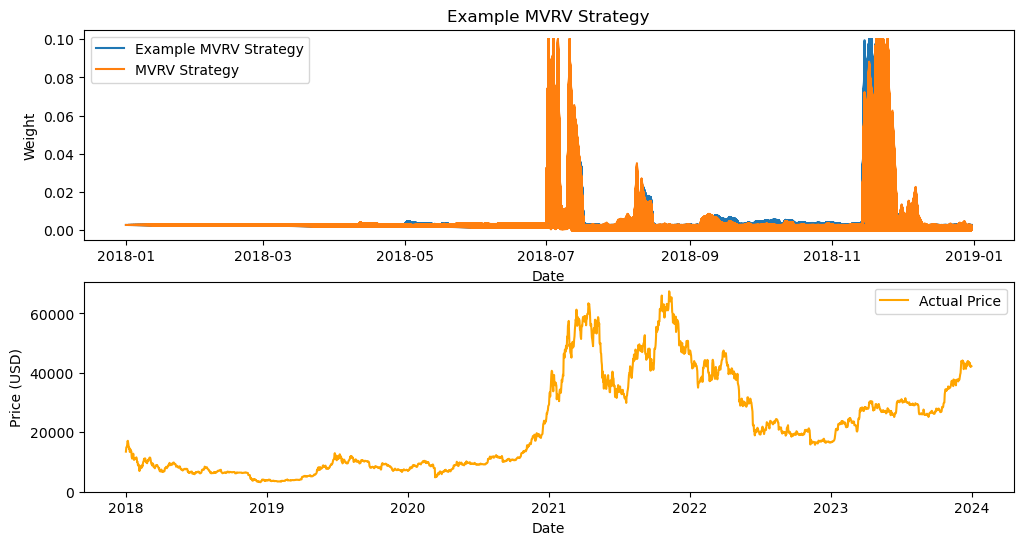

In [11]:
mvrv_plot_df = (
    mvrv_df.filter(pl.col("date") <= pl.date(2018, 12, 31))
    .select(["date", "weight"])
)
strategy_plot_df = (
    strategy_df.filter(pl.col("date") <= pl.date(2018, 12, 31))
    .select(["date", "weight"])
)

fig, ax = plt.subplots(2,1,figsize=(12, 6))
axs = ax.flatten()
axs[0].plot(strategy_plot_df["date"], strategy_plot_df["weight"], label="Example MVRV Strategy")
axs[0].plot(mvrv_plot_df["date"], mvrv_plot_df["weight"], label="MVRV Strategy") 
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Weight")
axs[0].set_title("Example MVRV Strategy")
axs[0].legend()

axs[1].plot(df["date"], df["price_usd"], label="Actual Price", color="orange")
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Price (USD)")
plt.legend()
plt.show()

In [12]:
from stacksats import BacktestConfig

example_bt = runner.backtest(
    example_strategy,
    config=BacktestConfig(
        start_date=str(start_date),
        end_date=str(end_date),
        output_dir="output",
    ),
    btc_df=df,
)

In [13]:
example_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,13485.080263,34.766505,29.876007,-4.890498
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,13500.285071,34.968165,29.935447,-5.032718
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,13517.096374,35.171063,30.001168,-5.169895
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,13533.895337,35.383081,30.066841,-5.31624
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,13550.888349,35.592341,30.133272,-5.459069
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,2412.72051,36.43953,3.924079,-32.515451
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,2404.949974,36.172452,3.719146,-32.453306
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,2406.059884,35.910124,3.748418,-32.161706


In [14]:
example_yearly = []
uniform_yearly = []
uniform_strategy = UniformStrategy()

for year in range(2018, 2024):
    example_result = strategy_utils.export_one_year(example_strategy, df, year, runner)
    if example_result is not None:
        example_yearly.append(example_result)

    uniform_result = strategy_utils.export_one_year(uniform_strategy, df, year, runner)
    if uniform_result is not None:
        uniform_yearly.append(uniform_result)

print("Example MVRV valid yearly exports:", len(example_yearly))
print("Uniform valid yearly exports:", len(uniform_yearly))

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
Example MVRV valid yearly exports: 6
Uniform valid yearly exports: 6


In [15]:
if not example_yearly:
    raise ValueError("No valid Example exports were produced.")

if not uniform_yearly:
    raise ValueError("No valid Uniform exports were produced.")

example_all = pl.concat(example_yearly).rename({"weight": "example_weight_raw"})
uniform_all = pl.concat(uniform_yearly).rename({"weight": "baseline_weight_raw"})

print("Example MVRV combined rows:", example_all.height)
print("Uniform combined rows:", uniform_all.height)

Example MVRV combined rows: 2190
Uniform combined rows: 2190


In [16]:
merged = (
    example_all
    .select(["date", "price_usd", "example_weight_raw"])
    .join(
        uniform_all.select(["date", "baseline_weight_raw"]),
        on="date",
        how="inner"
    )
    .sort("date")
)

print("Merged rows:", merged.height)

merged.head()

Merged rows: 2190


date,price_usd,example_weight_raw,baseline_weight_raw
datetime[μs],f64,f64,f64
2018-01-01 00:00:00,13466.31,0.00274,0.00274
2018-01-02 00:00:00,14888.11,0.00274,0.00274
2018-01-03 00:00:00,15098.14,0.00274,0.00274
2018-01-04 00:00:00,15144.99,0.00274,0.00274
2018-01-05 00:00:00,16960.01,0.00274,0.00274


In [17]:
example_sum = merged["example_weight_raw"].sum()
uniform_sum = merged["baseline_weight_raw"].sum()

merged = merged.with_columns([
    (pl.col("example_weight_raw") / example_sum).alias("example_weight"),
    (pl.col("baseline_weight_raw") / uniform_sum).alias("baseline_weight"),
])

print("Example normalized weight sum:", merged["example_weight"].sum())
print("Uniform normalized weight sum:", merged["baseline_weight"].sum())

Example normalized weight sum: 0.9999999999999999
Uniform normalized weight sum: 1.0000000000000002


In [18]:
total_budget_usd = 1000.0

merged = merged.with_columns([
    (pl.col("example_weight") * total_budget_usd).alias("example_usd"),
    (pl.col("baseline_weight") * total_budget_usd).alias("baseline_usd"),
])

merged = merged.with_columns([
    (pl.col("example_usd") / pl.col("price_usd")).alias("btc_accum_example"),
    (pl.col("baseline_usd") / pl.col("price_usd")).alias("btc_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("btc_accum_example") * 100_000_000).alias("sats_accum_example"),
    (pl.col("btc_accum_baseline") * 100_000_000).alias("sats_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("sats_accum_example") / pl.col("example_usd")).alias("sats_per_dollar_example"),
    (pl.col("sats_accum_baseline") / pl.col("baseline_usd")).alias("sats_per_dollar_baseline"),
])

total_dynamic_btc = merged["btc_accum_example"].sum()
total_baseline_btc = merged["btc_accum_baseline"].sum()

sats_per_dollar_dynamic = (total_dynamic_btc / total_budget_usd) * 100_000_000
sats_per_dollar_baseline = (total_baseline_btc / total_budget_usd) * 100_000_000

pct_diff_vs_baseline = (
    (total_dynamic_btc - total_baseline_btc) / total_baseline_btc
) * 100

performance_label = "better" if pct_diff_vs_baseline > 0 else "worse"

print(f"Total BTC accumulated, Example: {total_dynamic_btc:.6f}")
print(f"Total BTC accumulated, Uniform: {total_baseline_btc:.6f}")
print(f"Sats per dollar, Example: {sats_per_dollar_dynamic:.2f}")
print(f"Sats per dollar, Uniform: {sats_per_dollar_baseline:.2f}")
print(f"Example performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than Uniform")

Total BTC accumulated, Example: 0.081095
Total BTC accumulated, Uniform: 0.084188
Sats per dollar, Example: 8109.52
Sats per dollar, Uniform: 8418.79
Example performed 3.67% worse than Uniform


In [19]:
plot_df = merged.to_pandas()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year
plot_df["cycle_label"] = plot_df["date"].apply(plots.assign_cycle_label)

plot_df.head()

,date,price_usd,example_weight_raw,baseline_weight_raw,example_weight,baseline_weight,example_usd,baseline_usd,btc_accum_example,btc_accum_baseline,sats_accum_example,sats_accum_baseline,sats_per_dollar_example,sats_per_dollar_baseline,year,cycle_label
0,2018-01-01,13466.31,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000034,0.000034,3390.839841,3390.839841,7425.939251,7425.939251,2018,Cycle 3: 2018-2021
1,2018-01-02,14888.11,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000031,0.000031,3067.017940,3067.017940,6716.769288,6716.769288,2018,Cycle 3: 2018-2021
2,2018-01-03,15098.14,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000030,0.000030,3024.352699,3024.352699,6623.332410,6623.332410,2018,Cycle 3: 2018-2021
3,2018-01-04,15144.99,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000030,0.000030,3014.997069,3014.997069,6602.843581,6602.843581,2018,Cycle 3: 2018-2021
4,2018-01-05,16960.01,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000027,0.000027,2692.339241,2692.339241,5896.222939,5896.222939,2018,Cycle 3: 2018-2021


In [20]:
top_buy_points_list = []

for year, year_df in plot_df.groupby("year"):
    threshold = year_df["example_weight"].quantile(0.90)

    top_year_df = year_df[year_df["example_weight"] >= threshold].copy()
    top_year_df["top_buy_threshold_year"] = threshold

    top_buy_points_list.append(top_year_df)

top_buy_points = pd.concat(top_buy_points_list, ignore_index=True)

top_buy_points = top_buy_points.sort_values(
    ["year", "example_weight"],
    ascending=[True, False]
)

print("Top buy points:", len(top_buy_points))
top_buy_points[["date", "year", "price_usd", "example_weight", "top_buy_threshold_year"]].head()

Top buy points: 222


,date,year,price_usd,example_weight,top_buy_threshold_year
22,2018-07-02,2018,6615.02,0.012085,0.000527
31,2018-07-11,2018,6386.63,0.008779,0.000527
24,2018-07-04,2018,6577.03,0.008354,0.000527
34,2018-07-14,2018,6246.27,0.007842,0.000527
33,2018-07-13,2018,6207.56,0.007764,0.000527


In [21]:
plot_df.head()

,date,price_usd,example_weight_raw,baseline_weight_raw,example_weight,baseline_weight,example_usd,baseline_usd,btc_accum_example,btc_accum_baseline,sats_accum_example,sats_accum_baseline,sats_per_dollar_example,sats_per_dollar_baseline,year,cycle_label
0,2018-01-01,13466.31,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000034,0.000034,3390.839841,3390.839841,7425.939251,7425.939251,2018,Cycle 3: 2018-2021
1,2018-01-02,14888.11,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000031,0.000031,3067.017940,3067.017940,6716.769288,6716.769288,2018,Cycle 3: 2018-2021
2,2018-01-03,15098.14,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000030,0.000030,3024.352699,3024.352699,6623.332410,6623.332410,2018,Cycle 3: 2018-2021
3,2018-01-04,15144.99,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000030,0.000030,3014.997069,3014.997069,6602.843581,6602.843581,2018,Cycle 3: 2018-2021
4,2018-01-05,16960.01,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000027,0.000027,2692.339241,2692.339241,5896.222939,5896.222939,2018,Cycle 3: 2018-2021


In [22]:
cols = plots.StrategyColumns(
    weight="example_weight",
    spd="sats_per_dollar_example",
    sats_accum="sats_accum_example",
)

# Full period
full_plot = plots.plot_strategy_full_period(plot_df, cols, "Example-MVRV Strategy", ("2018-01-01", "2023-12-31"))
plt.show()

## MVRVPlusStrategy

Essentially the same as ExampleMVRV.

It starts by generating preference scores using the standard StackSats MVRV model. It adds two derived features: 21-day rolling volatility (plus_vol21) and 90-day rolling drawdown (plus_drawdown90), capturing recent risk and price stress. It requires several "overlay" features provided by the framework, such as netflow, exchange share, activity divergence, ROI context, liquidity impulse, miner pressure, and hash momentum.

The strategy dynamically scales the baseline preference up or down depending on the "zone" (deep value, overheated, neutral) using parameters like deep_value_boost, overheat_dampen, and neutral_scale.
It reduces allocation in the presence of:
- High realized or expected volatility.
- Large price drawdowns.
- Strong disagreement between value and trend signals.
- Lack of model confidence in favorable conditions.
- Additional small penalty for very high realized volatility.
The overlays (netflow, activity, ROI, etc.) are linearly combined into an “overlay” term using fixed weights, with risk and value zone gating applied to each

In [23]:
from stacksats.strategies.experimental.overlays import MVRVPlusStrategy

In [24]:
mvrv_plus = MVRVPlusStrategy()

In [25]:
example_bt = runner.backtest(
    mvrv_plus,
    config=BacktestConfig(
        start_date=str(start_date),
        end_date=str(end_date),
        output_dir="output",
    ),
    btc_df=df,
)
example_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,13107.300385,34.766505,28.399145,-6.36736
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,13132.085134,34.968165,28.496036,-6.472129
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,13158.363518,35.171063,28.598767,-6.572297
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,13184.913187,35.383081,28.702558,-6.680523
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,13211.524014,35.592341,28.806588,-6.785753
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,2428.716525,36.43953,4.345943,-32.093587
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,2416.559525,36.172452,4.025326,-32.147127
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,2414.617864,35.910124,3.974118,-31.936006


In [26]:
mvrv_plus_runner = runner.export(mvrv_plus, config, btc_df=df)
mvrv_plus_df = mvrv_plus_runner.to_dataframe()
mvrv_plus_df

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274
…,…,…,…,…,…
2023-01-01 00:00:00,2023-12-31 00:00:00,360.0,2023-12-27 00:00:00,43337.18,0.1
2023-01-01 00:00:00,2023-12-31 00:00:00,361.0,2023-12-28 00:00:00,42577.15,0.1
2023-01-01 00:00:00,2023-12-31 00:00:00,362.0,2023-12-29 00:00:00,41965.03,0.1


In [27]:
plus_yearly = []
uniform_yearly = []
uniform_strategy = UniformStrategy()

for year in range(2018, 2024):
    plus_result = strategy_utils.export_one_year(mvrv_plus, df, year, runner)
    if plus_result is not None:
        plus_yearly.append(plus_result)

    uniform_result = strategy_utils.export_one_year(uniform_strategy, df, year, runner)
    if uniform_result is not None:
        uniform_yearly.append(uniform_result)

print("MVRV plus valid yearly exports:", len(plus_yearly))
print("Uniform valid yearly exports:", len(uniform_yearly))

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
MVRV plus valid yearly exports: 6
Uniform valid yearly exports: 6


In [28]:
if not example_yearly:
    raise ValueError("No valid Example exports were produced.")

if not uniform_yearly:
    raise ValueError("No valid Uniform exports were produced.")

plus_all = pl.concat(plus_yearly).rename({"weight": "plus_weight_raw"})
uniform_all = pl.concat(uniform_yearly).rename({"weight": "baseline_weight_raw"})

print("MVRV plus combined rows:", plus_all.height)
print("Uniform combined rows:", uniform_all.height)




merged = (
    plus_all
    .select(["date", "price_usd", "plus_weight_raw"])
    .join(
        uniform_all.select(["date", "baseline_weight_raw"]),
        on="date",
        how="inner"
    )
    .sort("date")
)

print("Merged rows:", merged.height)

merged.head()


MVRV plus combined rows: 2190
Uniform combined rows: 2190
Merged rows: 2190


date,price_usd,plus_weight_raw,baseline_weight_raw
datetime[μs],f64,f64,f64
2018-01-01 00:00:00,13466.31,0.00274,0.00274
2018-01-02 00:00:00,14888.11,0.00274,0.00274
2018-01-03 00:00:00,15098.14,0.00274,0.00274
2018-01-04 00:00:00,15144.99,0.00274,0.00274
2018-01-05 00:00:00,16960.01,0.00274,0.00274


In [29]:
example_sum = merged["plus_weight_raw"].sum()
uniform_sum = merged["baseline_weight_raw"].sum()

merged = merged.with_columns([
    (pl.col("plus_weight_raw") / example_sum).alias("plus_weight"),
    (pl.col("baseline_weight_raw") / uniform_sum).alias("baseline_weight"),
])

print("Plus normalized weight sum:", merged["plus_weight"].sum())
print("Uniform normalized weight sum:", merged["baseline_weight"].sum())

Plus normalized weight sum: 1.0
Uniform normalized weight sum: 1.0000000000000002


In [30]:
total_budget_usd = 1000.0

merged = merged.with_columns([
    (pl.col("plus_weight") * total_budget_usd).alias("plus_usd"),
    (pl.col("baseline_weight") * total_budget_usd).alias("baseline_usd"),
])

merged = merged.with_columns([
    (pl.col("plus_usd") / pl.col("price_usd")).alias("btc_accum_plus"),
    (pl.col("baseline_usd") / pl.col("price_usd")).alias("btc_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("btc_accum_plus") * 100_000_000).alias("sats_accum_plus"),
    (pl.col("btc_accum_baseline") * 100_000_000).alias("sats_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("sats_accum_plus") / pl.col("plus_usd")).alias("sats_per_dollar_plus"),
    (pl.col("sats_accum_baseline") / pl.col("baseline_usd")).alias("sats_per_dollar_baseline"),
])

total_dynamic_btc = merged["btc_accum_plus"].sum()
total_baseline_btc = merged["btc_accum_baseline"].sum()

sats_per_dollar_dynamic = (total_dynamic_btc / total_budget_usd) * 100_000_000
sats_per_dollar_baseline = (total_baseline_btc / total_budget_usd) * 100_000_000

pct_diff_vs_baseline = (
    (total_dynamic_btc - total_baseline_btc) / total_baseline_btc
) * 100

performance_label = "better" if pct_diff_vs_baseline > 0 else "worse"

print(f"Total BTC accumulated, Plus: {total_dynamic_btc:.6f}")
print(f"Total BTC accumulated, Uniform: {total_baseline_btc:.6f}")
print(f"Sats per dollar, Plus: {sats_per_dollar_dynamic:.2f}")
print(f"Sats per dollar, Uniform: {sats_per_dollar_baseline:.2f}")
print(f"Plus performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than Uniform")

Total BTC accumulated, Plus: 0.080187
Total BTC accumulated, Uniform: 0.084188
Sats per dollar, Plus: 8018.70
Sats per dollar, Uniform: 8418.79
Plus performed 4.75% worse than Uniform


In [31]:
plot_df = merged.to_pandas()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year
plot_df["cycle_label"] = plot_df["date"].apply(plots.assign_cycle_label)

plot_df.head()

,date,price_usd,plus_weight_raw,baseline_weight_raw,plus_weight,baseline_weight,plus_usd,baseline_usd,btc_accum_plus,btc_accum_baseline,sats_accum_plus,sats_accum_baseline,sats_per_dollar_plus,sats_per_dollar_baseline,year,cycle_label
0,2018-01-01,13466.31,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000034,0.000034,3390.839841,3390.839841,7425.939251,7425.939251,2018,Cycle 3: 2018-2021
1,2018-01-02,14888.11,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000031,0.000031,3067.017940,3067.017940,6716.769288,6716.769288,2018,Cycle 3: 2018-2021
2,2018-01-03,15098.14,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000030,0.000030,3024.352699,3024.352699,6623.332410,6623.332410,2018,Cycle 3: 2018-2021
3,2018-01-04,15144.99,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000030,0.000030,3014.997069,3014.997069,6602.843581,6602.843581,2018,Cycle 3: 2018-2021
4,2018-01-05,16960.01,0.00274,0.00274,0.000457,0.000457,0.456621,0.456621,0.000027,0.000027,2692.339241,2692.339241,5896.222939,5896.222939,2018,Cycle 3: 2018-2021


In [32]:
top_buy_points_list = []

for year, year_df in plot_df.groupby("year"):
    threshold = year_df["plus_weight"].quantile(0.90)

    top_year_df = year_df[year_df["plus_weight"] >= threshold].copy()
    top_year_df["top_buy_threshold_year"] = threshold

    top_buy_points_list.append(top_year_df)

top_buy_points = pd.concat(top_buy_points_list, ignore_index=True)

top_buy_points = top_buy_points.sort_values(
    ["year", "plus_weight"],
    ascending=[True, False]
)

print("Top buy points:", len(top_buy_points))
top_buy_points[["date", "year", "price_usd", "plus_weight", "top_buy_threshold_year"]].head()

Top buy points: 226


,date,year,price_usd,plus_weight,top_buy_threshold_year
13,2018-07-16,2018,6719.11,0.004018,0.000876
12,2018-07-15,2018,6343.53,0.003788,0.000876
14,2018-07-17,2018,7325.01,0.003578,0.000876
11,2018-07-14,2018,6246.27,0.003433,0.000876
15,2018-07-18,2018,7344.00,0.003117,0.000876


In [33]:
cols = plots.StrategyColumns(
    weight="plus_weight",
    spd="sats_per_dollar_plus",
    sats_accum="sats_accum_plus",
)

# Full period
full_plot = plots.plot_strategy_full_period(plot_df, cols, "MVRV Plus Strategy", ("2018-01-01", "2023-12-31"))
plt.show()